In [28]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations

# Define imbalance ratios and file paths
ratios = [1, 2, 5, 10, 15, 20, 30, 40, 45, 50]
metrics = []
cv_box = {'LIME': [], 'SHAP': []}     # For boxplots of CV
csi_box = {'LIME': []}               # distributions of feature CSIs
vsi_box = {'LIME': []}               # distributions of pairwise Jaccards (internal VSI)

for ratio in ratios:
    # Load the 100-run explanation CSVs for this ratio
    lime_file = f'results/iterations/lime_iterations_{ratio}.csv'
    shap_file = f'results/iterations/shap_iterations_{ratio}.csv'
    lime_df = pd.read_csv(lime_file)
    shap_df = pd.read_csv(shap_file)
    
    # Ensure features (columns) are aligned
    features = list(lime_df.columns)
    P = len(features)
    n_runs = len(lime_df)

    # ==== Compute CV for each feature, then aggregate ====
    # CoV = std/mean for each feature
    lime_std = lime_df.std(axis=0)
    lime_mean = lime_df.mean(axis=0)
    # avoid division by zero: add small eps if needed
    eps = 1e-8
    lime_cv = (lime_std / (lime_mean.abs() + eps)).replace([np.inf, -np.inf], np.nan).fillna(0)
    shap_std = shap_df.std(axis=0)
    shap_mean = shap_df.mean(axis=0)
    shap_cv = (shap_std / (shap_mean.abs() + eps)).replace([np.inf, -np.inf], np.nan).fillna(0)
    # median CV across features as summary
    cv_lime = np.nanmedian(lime_cv.values)
    cv_shap = np.nanmedian(shap_cv.values)
    cv_box['LIME'].append(lime_cv.values)
    cv_box['SHAP'].append(shap_cv.values)
    
    # ==== Compute SRA for K=1..5 ====
    # For each run, get ranks of features (1=highest importance)
    def get_rank_matrix(df):
        # df: runs x features
        n_runs, n_features = df.shape
        rank_mat = np.zeros((n_runs, n_features), dtype=int)
        for i in range(n_runs):
            vals = df.iloc[i].values
            # argsort descending: index of features sorted by decreasing importance
            sorted_idx = np.argsort(-vals)
            # Assign ranks: top gets rank 1
            ranks = np.empty(n_features, dtype=int)
            ranks[sorted_idx] = np.arange(1, n_features+1)
            rank_mat[i] = ranks
        return rank_mat

    lime_ranks = get_rank_matrix(lime_df)
    shap_ranks = get_rank_matrix(shap_df)

    sra_vals_lime = {}
    sra_vals_shap = {}
    for K in range(1, 6):
        # Define set S of features appearing in top-K of any run
        S_lime = set(np.where((lime_ranks <= K))[1])
        S_shap = set(np.where((shap_ranks <= K))[1])
        # Compute pooled variance of ranks in S
        def compute_sra(rank_mat, S):
            if len(S) == 0:
                return np.nan
            S = list(S)
            ranks_S = rank_mat[:, S]          # shape (n_runs, len(S))
            avg_rank = ranks_S.mean(axis=0)   # average rank per feature in S
            # sum of squared devs
            dev2 = ((ranks_S - avg_rank)**2).sum()
            # pooled variance (per-depth)
            return np.sqrt(dev2 / (rank_mat.shape[0] * len(S)))
        sra_vals_lime[K] = compute_sra(lime_ranks, S_lime)
        sra_vals_shap[K] = compute_sra(shap_ranks, S_shap)

    # ==== Compute CSI and VSI for LIME only ====
    # CSI: 1 - (std / max_std) for each feature
    max_std = lime_std.max() + eps
    csi_values = 1.0 - (lime_std / max_std)
    csi_values = np.clip(csi_values, 0, 1)
    # Record feature-wise CSI for boxplot later
    csi_box['LIME'].append(csi_values.values)

    # VSI (internal): compute Jaccard for top-5 feature sets between runs
    topK = 5
    # get sets of top-K features for each run
    sets = []
    for i in range(n_runs):
        # indices of topK features by absolute importance (descending)
        top_idx = np.argsort(-lime_df.iloc[i].values)[:topK]
        sets.append(set(top_idx))
    # compute all pairwise Jaccard similarities
    import numpy as np
    import itertools
    
    rng = np.random.default_rng(42)
    pair_gen = itertools.combinations(range(n_runs), 2)
    subset = list(itertools.islice(pair_gen, 100000))  # safe slice
    sample_pairs = rng.choice(subset, size=10000, replace=False)
    jsims = []
    for (a, b) in sample_pairs:
        s1, s2 = sets[a], sets[b]
        sim = len(s1 & s2) / len(s1 | s2) if s1 or s2 else 1.0
        jsims.append(sim)
    vsi_box['LIME'].append(jsims)
    # Also record average VSI (for metrics CSV, though boxplot uses jsims)
    avg_vsi = np.mean(jsims) * 100  # as percentage

    # Aggregate CSI (e.g. mean) for reporting
    avg_csi = np.mean(csi_values)

    # Save metrics for this ratio
    metrics.append({
        'ratio': ratio, 'method': 'LIME',
        'SRA1': sra_vals_lime[1], 'SRA2': sra_vals_lime[2],
        'SRA3': sra_vals_lime[3], 'SRA4': sra_vals_lime[4],
        'SRA5': sra_vals_lime[5], 'CV_med': cv_lime,
        'CSI': avg_csi, 'VSI': avg_vsi
    })
    metrics.append({
        'ratio': ratio, 'method': 'SHAP',
        'SRA1': sra_vals_shap[1], 'SRA2': sra_vals_shap[2],
        'SRA3': sra_vals_shap[3], 'SRA4': sra_vals_shap[4],
        'SRA5': sra_vals_shap[5], 'CV_med': cv_shap,
        'CSI': None,    # not applicable for SHAP
        'VSI': None     # not applicable
    })

# Save all metrics to CSV
metrics_df = pd.DataFrame(metrics)
metrics_df.to_csv('metrics/explanation_stability_metrics.csv', index=False)

# ==== Generate plots ====

# 1. Line plots of average SRA vs imbalance for K=1..5 (separate for LIME/SHAP)
fig, axs = plt.subplots(1, 2, figsize=(12,5))
for (method, ax) in zip(['LIME','SHAP'], axs):
    for K in range(1,6):
        y = [row[f'SRA{K}'] for _, row in metrics_df[metrics_df.method==method].iterrows()]
        ax.plot(ratios, y, marker='o', label=f'K={K}')
    ax.set_xscale('log')
    ax.set_xlabel('Imbalance Ratio (%)')
    ax.set_ylabel('SRA (pooled std dev of ranks)')
    ax.set_title(f'{method} SRA vs Imbalance')
    ax.legend(title='Top-K')
    ax.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('plots/SRA_vs_imbalance.png')
plt.close()

# 2. Boxplots of CV vs imbalance (LIME vs SHAP)
fig, axs = plt.subplots(1, 2, figsize=(12,5))
for i, method in enumerate(['LIME','SHAP']):
    data = cv_box[method]
    axs[i].boxplot(data, positions=range(len(ratios)), showmeans=False)
    axs[i].set_xticks(range(len(ratios)))
    axs[i].set_xticklabels([str(r) for r in ratios], rotation=45)
    axs[i].set_xlabel('Imbalance Ratio (%)')
    axs[i].set_ylabel('Feature CoV')
    axs[i].set_title(f'{method} CV across Features')
    axs[i].grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('plots/CV_boxplots.png')
plt.close()

# 3. Boxplots of CSI and VSI (internal LIME stability) vs imbalance
# For CSI: use distribution of feature CSIs; for VSI: distribution of all pairwise Jaccards.
fig, axs = plt.subplots(1, 2, figsize=(12,5))
# CSI distribution
data_csi = csi_box['LIME']  # list of arrays of CSI per feature
axs[0].boxplot(data_csi, positions=range(len(ratios)), showmeans=False)
axs[0].set_xticks(range(len(ratios)))
axs[0].set_xticklabels([str(r) for r in ratios], rotation=45)
axs[0].set_xlabel('Imbalance Ratio (%)')
axs[0].set_ylabel('Feature CSI (1 – normalized STD)')
axs[0].set_title('LIME Coefficient Stability Index (CSI)')
axs[0].grid(axis='y', linestyle='--', alpha=0.5)
# VSI distribution (internal): use Jaccard sims
data_vsi = vsi_box['LIME']
axs[1].boxplot(data_vsi, positions=range(len(ratios)), showmeans=False)
axs[1].set_xticks(range(len(ratios)))
axs[1].set_xticklabels([str(r) for r in ratios], rotation=45)
axs[1].set_xlabel('Imbalance Ratio (%)')
axs[1].set_ylabel('Pairwise Jaccard (top-5 features)')
axs[1].set_title('LIME Variable Stability Index (VSI) – Internal')
axs[1].grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('plots/CSI_VSI_boxplots.png')
plt.close()

Processing SHAP explanations for 1% imbalance
Processing SHAP explanations for 2% imbalance
Processing SHAP explanations for 5% imbalance
Processing SHAP explanations for 10% imbalance
Processing SHAP explanations for 15% imbalance
Processing SHAP explanations for 20% imbalance
Processing SHAP explanations for 30% imbalance
Processing SHAP explanations for 40% imbalance
Processing SHAP explanations for 45% imbalance
Processing SHAP explanations for 50% imbalance


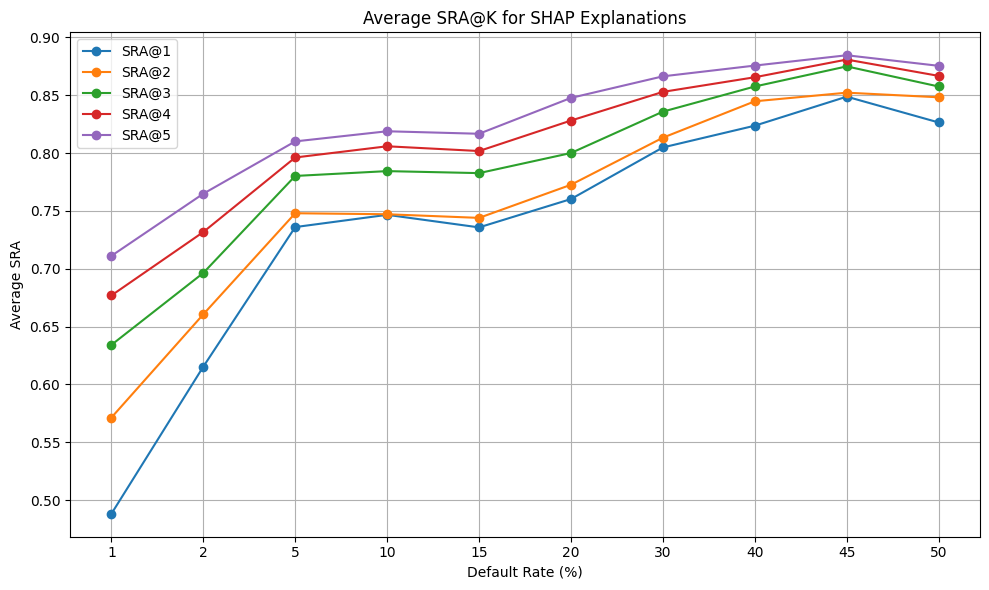

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import rankdata

# === CONFIGURATION ===
ratios = ["1", "2", "5", "10", "15", "20", "30", "40", "45", "50"]
k_list = [1, 2, 3, 4, 5]
sra_scores = {k: [] for k in k_list}

def compute_sra_at_k(ranked_lists, k):
    """
    ranked_lists: List of ranked feature indices for the same instance over runs
    k: depth of ranking list to evaluate SRA@k
    """
    topk_lists = [tuple(r[:k]) for r in ranked_lists]
    match_matrix = np.zeros((len(topk_lists), len(topk_lists)))
    
    for i in range(len(topk_lists)):
        for j in range(len(topk_lists)):
            match_matrix[i, j] = len(set(topk_lists[i]).intersection(set(topk_lists[j]))) / k
    
    return match_matrix[np.triu_indices(len(topk_lists), k=1)].mean()

# === MAIN LOOP ===
for ratio in ratios:
    print(f"Processing SHAP explanations for {ratio}% imbalance")
    df = pd.read_csv(f"results/iterations/shap_iterations_{ratio}.csv")
    feature_cols = [col for col in df.columns if col not in ['iteration']]
    
    # Group by iteration → list of DataFrames (each run)
    runs = [df[df['iteration'] == i][feature_cols].values for i in range(100)]

    # Transpose to per-instance
    n_instances = runs[0].shape[0]
    
    for k in k_list:
        sra_per_instance = []
        for inst_idx in range(n_instances):
            rankings = [np.argsort(-run[inst_idx]) for run in runs]  # - for descending
            sra = compute_sra_at_k(rankings, k)
            sra_per_instance.append(sra)
        avg_sra = np.mean(sra_per_instance)
        sra_scores[k].append(avg_sra)

# === PLOT ===
plt.figure(figsize=(10, 6))
for k in k_list:
    plt.plot(ratios, sra_scores[k], marker='o', label=f'SRA@{k}')
plt.xlabel("Default Rate (%)")
plt.ylabel("Average SRA")
plt.title("Average SRA@K for SHAP Explanations")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Processing LIME explanations for 1% imbalance
Processing LIME explanations for 2% imbalance
Processing LIME explanations for 5% imbalance
Processing LIME explanations for 10% imbalance
Processing LIME explanations for 15% imbalance
Processing LIME explanations for 20% imbalance
Processing LIME explanations for 30% imbalance
Processing LIME explanations for 40% imbalance
Processing LIME explanations for 45% imbalance
Processing LIME explanations for 50% imbalance


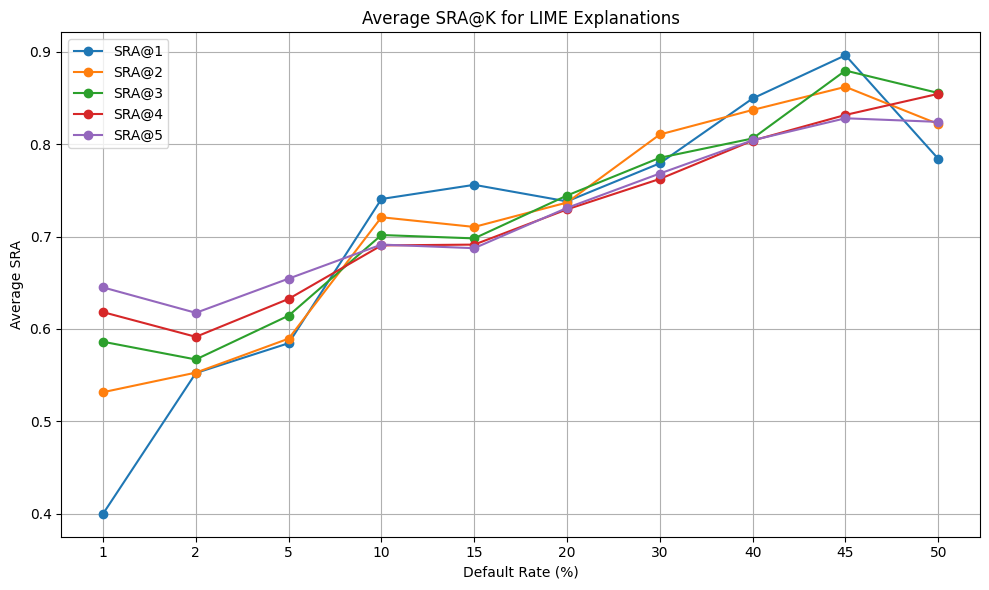

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import rankdata

# === CONFIGURATION ===
ratios = ["1", "2", "5", "10", "15", "20", "30", "40", "45", "50"]
k_list = [1, 2, 3, 4, 5]
sra_scores_lime = {k: [] for k in k_list}

def compute_sra_at_k(ranked_lists, k):
    topk_lists = [tuple(r[:k]) for r in ranked_lists]
    match_matrix = np.zeros((len(topk_lists), len(topk_lists)))
    
    for i in range(len(topk_lists)):
        for j in range(len(topk_lists)):
            match_matrix[i, j] = len(set(topk_lists[i]).intersection(set(topk_lists[j]))) / k
    
    return match_matrix[np.triu_indices(len(topk_lists), k=1)].mean()

# === MAIN LOOP ===
for ratio in ratios:
    print(f"Processing LIME explanations for {ratio}% imbalance")
    df = pd.read_csv(f"results/iterations/lime_iterations_{ratio}.csv")
    feature_cols = [col for col in df.columns if col not in ['iteration']]
    
    runs = [df[df['iteration'] == i][feature_cols].values for i in range(100)]
    n_instances = runs[0].shape[0]
    
    for k in k_list:
        sra_per_instance = []
        for inst_idx in range(n_instances):
            rankings = [np.argsort(-run[inst_idx]) for run in runs]
            sra = compute_sra_at_k(rankings, k)
            sra_per_instance.append(sra)
        avg_sra = np.mean(sra_per_instance)
        sra_scores_lime[k].append(avg_sra)

# === PLOT ===
plt.figure(figsize=(10, 6))
for k in k_list:
    plt.plot(ratios, sra_scores_lime[k], marker='o', label=f'SRA@{k}')
plt.xlabel("Default Rate (%)")
plt.ylabel("Average SRA")
plt.title("Average SRA@K for LIME Explanations")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Processing SHAP for 1% imbalance
Processing SHAP for 2% imbalance
Processing SHAP for 5% imbalance
Processing SHAP for 10% imbalance
Processing SHAP for 15% imbalance
Processing SHAP for 20% imbalance
Processing SHAP for 30% imbalance
Processing SHAP for 40% imbalance
Processing SHAP for 45% imbalance
Processing SHAP for 50% imbalance
Processing LIME for 1% imbalance
Processing LIME for 2% imbalance
Processing LIME for 5% imbalance
Processing LIME for 10% imbalance
Processing LIME for 15% imbalance
Processing LIME for 20% imbalance
Processing LIME for 30% imbalance
Processing LIME for 40% imbalance
Processing LIME for 45% imbalance
Processing LIME for 50% imbalance


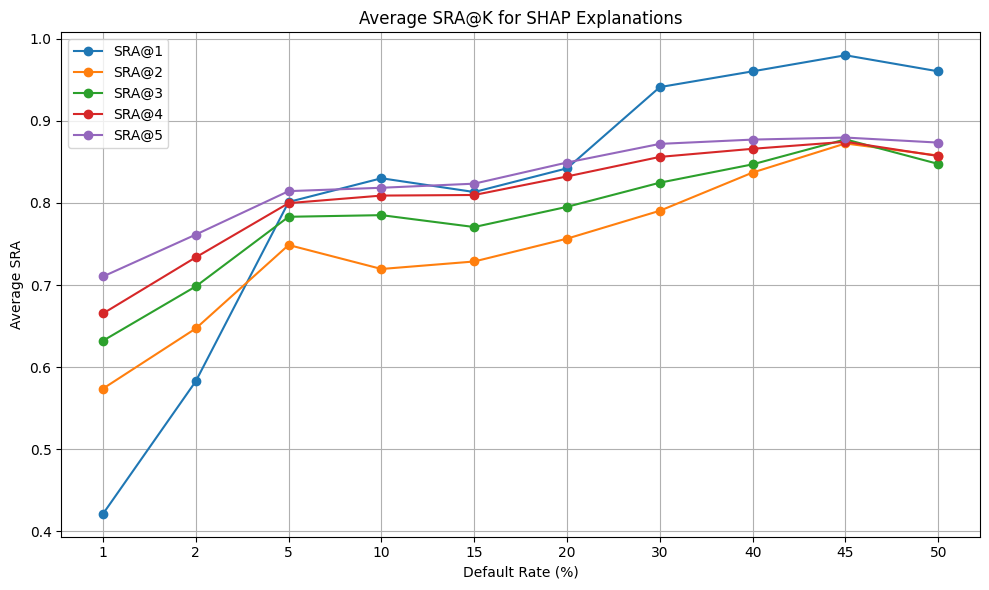

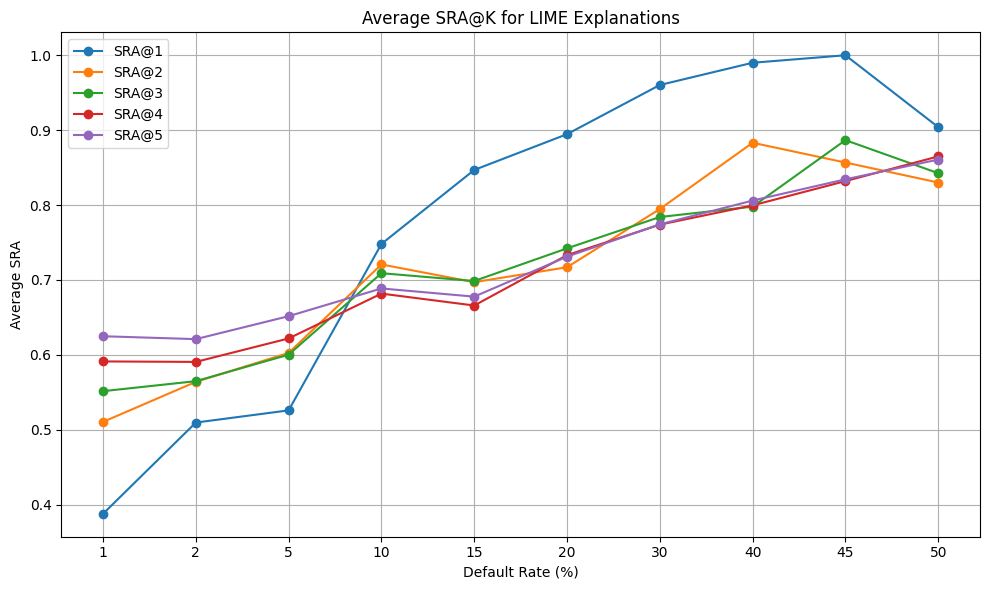

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# CONFIGURATION
# ==============================
ratios = ["1", "2", "5", "10", "15", "20", "30", "40", "45", "50"]
k_list = [1, 2, 3, 4, 5]

sra_scores_shap = {k: [] for k in k_list}
sra_scores_lime = {k: [] for k in k_list}

eps = 1e-8

# ==============================
# SRA FUNCTION (Top-K Jaccard)
# ==============================
def compute_sra_at_k(rankings, k):
    sims = []
    n = len(rankings)
    
    for i in range(n):
        for j in range(i+1, n):
            s1 = set(rankings[i][:k])
            s2 = set(rankings[j][:k])
            sim = len(s1 & s2) / k
            sims.append(sim)
    
    return np.mean(sims)

# ==============================
# GENERIC SRA COMPUTATION
# ==============================
def compute_sra_for_method(file_prefix, sra_scores):
    
    for ratio in ratios:
        print(f"Processing {file_prefix.upper()} for {ratio}% imbalance")
        
        df = pd.read_csv(f"results/iterations/{file_prefix}_iterations_{ratio}.csv")
        feature_cols = [col for col in df.columns if col != 'iteration']
        
        # collect runs
        runs = [df[df['iteration'] == i][feature_cols].values for i in range(100)]
        n_instances = runs[0].shape[0]

        # OPTIONAL: focus on important instances (uncomment if needed)
        # importance_scores = np.mean([np.sum(np.abs(run), axis=1) for run in runs], axis=0)
        # important_idx = np.argsort(-importance_scores)[:len(importance_scores)//2]
        # instance_range = important_idx
        
        instance_range = range(n_instances)

        for k in k_list:
            sra_per_instance = []

            for inst_idx in instance_range:
                rankings = []

                for run in runs:
                    vals = np.abs(run[inst_idx])

                    # 🔥 normalize (VERY IMPORTANT)
                    vals = vals / (np.sum(vals) + eps)

                    ranked = np.argsort(-vals)
                    rankings.append(ranked)

                sra = compute_sra_at_k(rankings, k)
                sra_per_instance.append(sra)

            # 🔥 use median (robust like papers)
            avg_sra = np.median(sra_per_instance)
            sra_scores[k].append(avg_sra)


# ==============================
# RUN FOR SHAP
# ==============================
compute_sra_for_method("shap", sra_scores_shap)

# ==============================
# RUN FOR LIME
# ==============================
compute_sra_for_method("lime", sra_scores_lime)

# ==============================
# PLOT SHAP
# ==============================
plt.figure(figsize=(10, 6))
for k in k_list:
    plt.plot(ratios, sra_scores_shap[k], marker='o', label=f'SRA@{k}')
plt.xlabel("Default Rate (%)")
plt.ylabel("Average SRA")
plt.title("Average SRA@K for SHAP Explanations")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ==============================
# PLOT LIME
# ==============================
plt.figure(figsize=(10, 6))
for k in k_list:
    plt.plot(ratios, sra_scores_lime[k], marker='o', label=f'SRA@{k}')
plt.xlabel("Default Rate (%)")
plt.ylabel("Average SRA")
plt.title("Average SRA@K for LIME Explanations")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Processing CV for 1% imbalance
Processing CV for 2% imbalance
Processing CV for 5% imbalance
Processing CV for 10% imbalance
Processing CV for 15% imbalance
Processing CV for 20% imbalance
Processing CV for 30% imbalance
Processing CV for 40% imbalance
Processing CV for 45% imbalance
Processing CV for 50% imbalance


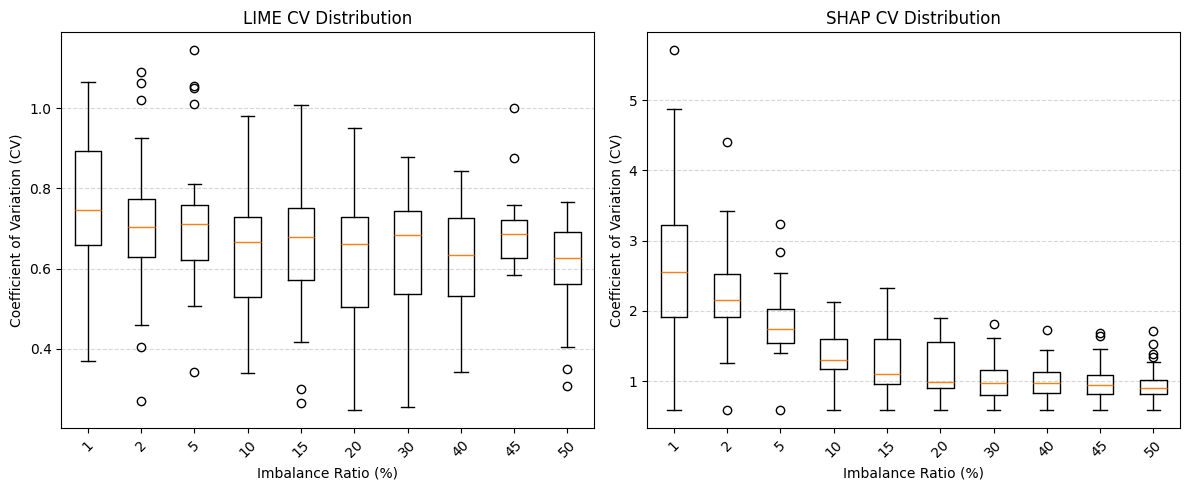

In [5]:
# ==============================
# NEW CELL: CV + PLOT
# ==============================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Imbalance ratios
ratios = [1, 2, 5, 10, 15, 20, 30, 40, 45, 50]

# Storage
cv_box = {'LIME': [], 'SHAP': []}
cv_summary = {'LIME': [], 'SHAP': []}

eps = 1e-8

for ratio in ratios:
    print(f"Processing CV for {ratio}% imbalance")
    
    # Load data
    lime_df = pd.read_csv(f'results/iterations/lime_iterations_{ratio}.csv')
    shap_df = pd.read_csv(f'results/iterations/shap_iterations_{ratio}.csv')

    # ==============================
    # LIME CV
    # ==============================
    lime_std = lime_df.std(axis=0)
    lime_mean = lime_df.mean(axis=0)

    lime_cv = lime_std / (np.abs(lime_mean) + eps)
    lime_cv = lime_cv.replace([np.inf, -np.inf], np.nan).fillna(0)

    cv_box['LIME'].append(lime_cv.values)
    cv_summary['LIME'].append(np.median(lime_cv.values))  # summary line

    # ==============================
    # SHAP CV
    # ==============================
    shap_std = shap_df.std(axis=0)
    shap_mean = shap_df.mean(axis=0)

    shap_cv = shap_std / (np.abs(shap_mean) + eps)
    shap_cv = shap_cv.replace([np.inf, -np.inf], np.nan).fillna(0)

    cv_box['SHAP'].append(shap_cv.values)
    cv_summary['SHAP'].append(np.median(shap_cv.values))

# ==============================
# 📊 BOXPLOT (distribution)
# ==============================

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

for i, method in enumerate(['LIME', 'SHAP']):
    axs[i].boxplot(cv_box[method], positions=range(len(ratios)))
    axs[i].set_xticks(range(len(ratios)))
    axs[i].set_xticklabels([str(r) for r in ratios], rotation=45)
    axs[i].set_xlabel('Imbalance Ratio (%)')
    axs[i].set_ylabel('Coefficient of Variation (CV)')
    axs[i].set_title(f'{method} CV Distribution')
    axs[i].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()



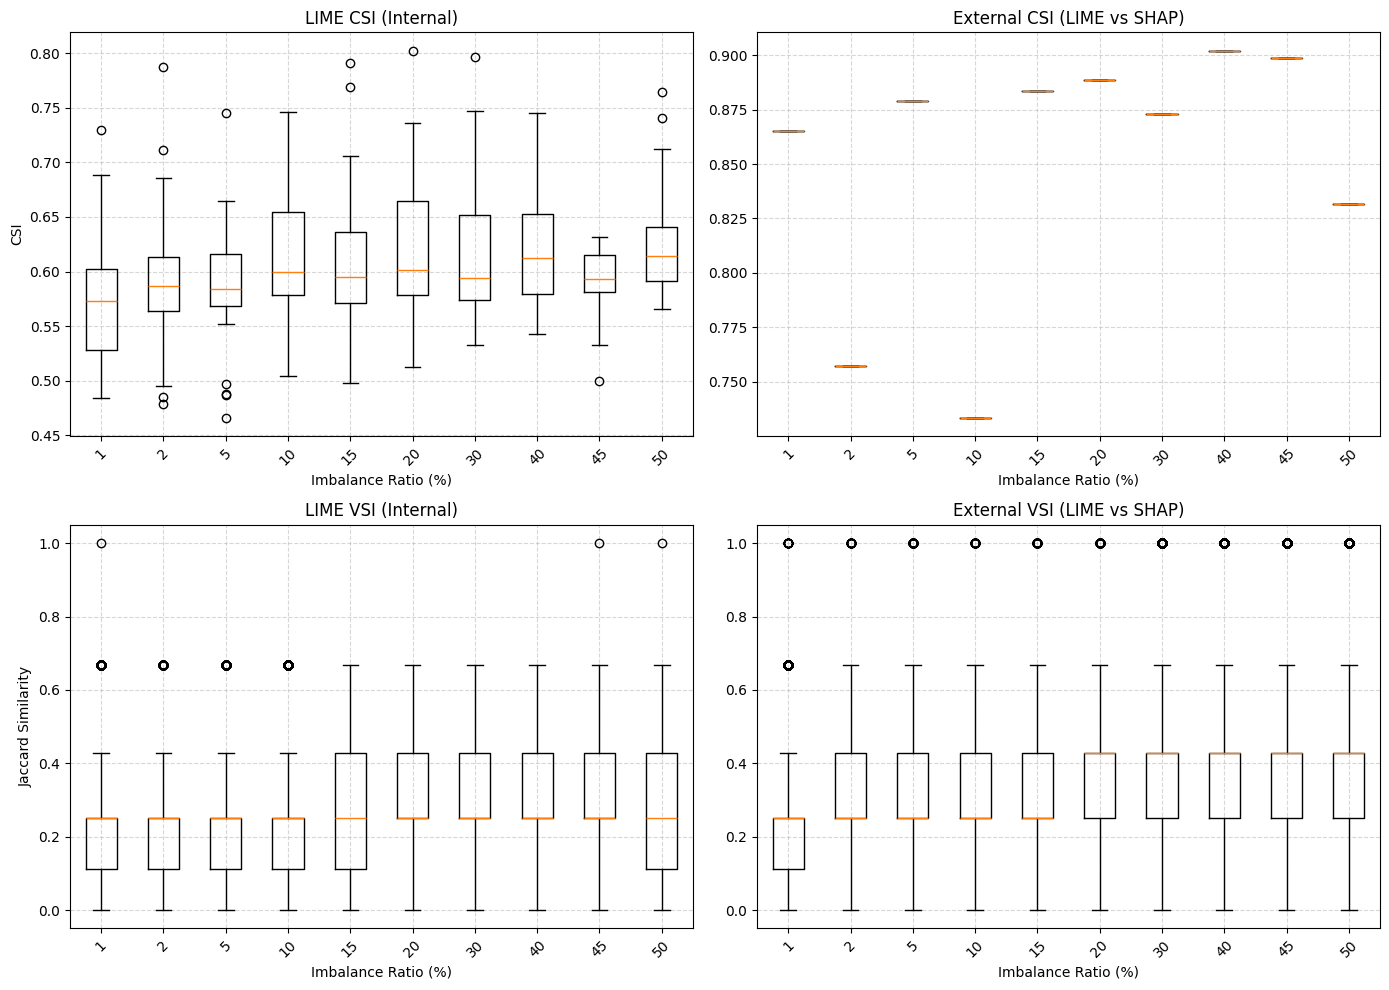

In [2]:
# ==============================
# NEW CELL: External Stability
# ==============================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import itertools

ratios = [1, 2, 5, 10, 15, 20, 30, 40, 45, 50]

# Storage
csi_box = {'LIME': [], 'EXT_CSI': []}
vsi_box = {'LIME': [], 'EXT_VSI': []}

eps = 1e-8

for ratio in ratios:
    # Load data
    lime_df = pd.read_csv(f'results/iterations/lime_iterations_{ratio}.csv')
    shap_df = pd.read_csv(f'results/iterations/shap_iterations_{ratio}.csv')

    n_runs = len(lime_df)

    # =====================================
    # ✅ INTERNAL CSI (LIME)
    # =====================================
    # ==== FIXED CSI (Internal - LIME) ====
    lime_std = lime_df.std(axis=0)
    lime_mean = lime_df.mean(axis=0)
    
    lime_cv = lime_std / (np.abs(lime_mean) + eps)
    lime_cv = lime_cv.replace([np.inf, -np.inf], np.nan).fillna(0)
    
    csi_values = 1 / (1 + lime_cv)
    csi_box['LIME'].append(csi_values.values)

    # =====================================
    # ✅ INTERNAL VSI (LIME)
    # =====================================
    topK = 5
    lime_sets = []

    for i in range(n_runs):
        top_idx = np.argsort(-lime_df.iloc[i].values)[:topK]
        lime_sets.append(set(top_idx))

    pair_gen = itertools.combinations(range(n_runs), 2)
    subset = list(itertools.islice(pair_gen, 100000))

    rng = np.random.default_rng(42)
    indices = rng.choice(len(subset), size=10000, replace=False)
    sample_pairs = [subset[i] for i in indices]

    jsims = []
    for (a, b) in sample_pairs:
        s1, s2 = lime_sets[a], lime_sets[b]
        sim = len(s1 & s2) / len(s1 | s2) if s1 or s2 else 1.0
        jsims.append(sim)

    vsi_box['LIME'].append(jsims)

    # =====================================
    # ✅ EXTERNAL VSI (LIME vs SHAP)
    # =====================================
    lime_sets = []
    shap_sets = []

    for i in range(n_runs):
        lime_top = set(np.argsort(-lime_df.iloc[i].values)[:topK])
        shap_top = set(np.argsort(-shap_df.iloc[i].values)[:topK])

        lime_sets.append(lime_top)
        shap_sets.append(shap_top)

    ext_jsims = []
    for i in range(n_runs):
        s1, s2 = lime_sets[i], shap_sets[i]
        sim = len(s1 & s2) / len(s1 | s2) if s1 or s2 else 1.0
        ext_jsims.append(sim)

    vsi_box['EXT_VSI'].append(ext_jsims)

    # =====================================
    # ✅ EXTERNAL CSI (feature agreement)
    # =====================================
    
    # ==== FIXED EXTERNAL CSI ====
    from scipy.stats import spearmanr
    
    lime_mean = lime_df.mean(axis=0)
    shap_mean = shap_df.mean(axis=0)
    
    corr, _ = spearmanr(lime_mean, shap_mean)
    ext_csi_value = (corr + 1) / 2  # normalize to [0,1]
    
    # store as constant array for boxplot compatibility
    ext_csi = np.full_like(lime_mean.values, ext_csi_value)
    
    csi_box['EXT_CSI'].append(ext_csi)

# =====================================
# 📊 COMBINED PLOTS
# =====================================

fig, axs = plt.subplots(2, 2, figsize=(14, 10))

# ---- Internal CSI
axs[0, 0].boxplot(csi_box['LIME'], positions=range(len(ratios)))
axs[0, 0].set_title('LIME CSI (Internal)')
axs[0, 0].set_ylabel('CSI')

# ---- External CSI
axs[0, 1].boxplot(csi_box['EXT_CSI'], positions=range(len(ratios)))
axs[0, 1].set_title('External CSI (LIME vs SHAP)')

# ---- Internal VSI
axs[1, 0].boxplot(vsi_box['LIME'], positions=range(len(ratios)))
axs[1, 0].set_title('LIME VSI (Internal)')
axs[1, 0].set_ylabel('Jaccard Similarity')

# ---- External VSI
axs[1, 1].boxplot(vsi_box['EXT_VSI'], positions=range(len(ratios)))
axs[1, 1].set_title('External VSI (LIME vs SHAP)')

# Formatting
for ax in axs.flat:
    ax.set_xticks(range(len(ratios)))
    ax.set_xticklabels([str(r) for r in ratios], rotation=45)
    ax.set_xlabel('Imbalance Ratio (%)')
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('plots/combined_internal_external_stability.png')
plt.show()

Processing SHAP explanations for 1% imbalance
Processing SHAP explanations for 2% imbalance
Processing SHAP explanations for 5% imbalance
Processing SHAP explanations for 10% imbalance
Processing SHAP explanations for 15% imbalance
Processing SHAP explanations for 20% imbalance
Processing SHAP explanations for 30% imbalance
Processing SHAP explanations for 40% imbalance
Processing SHAP explanations for 45% imbalance
Processing SHAP explanations for 50% imbalance


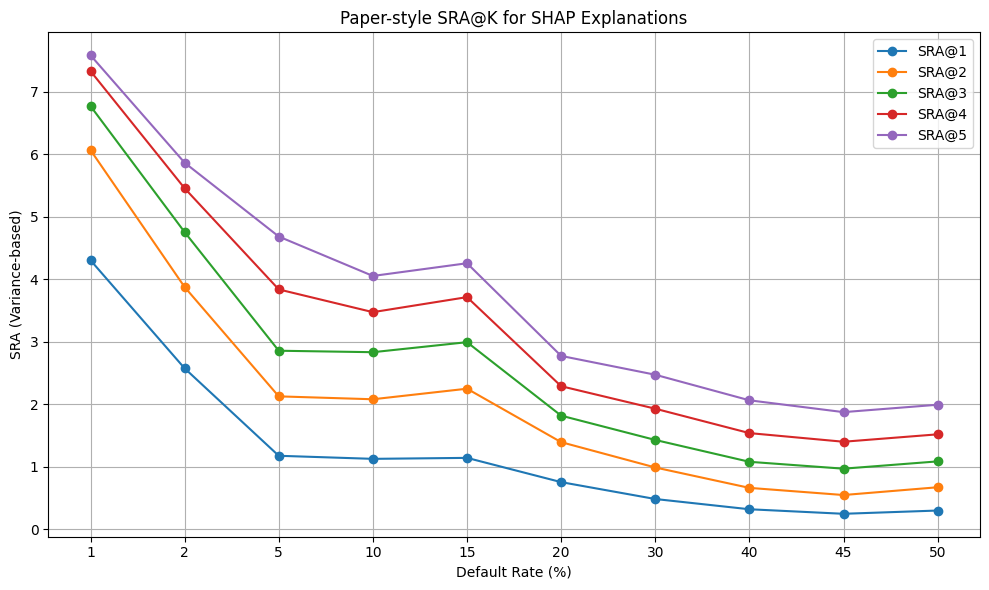

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# === CONFIGURATION ===
ratios = ["1", "2", "5", "10", "15", "20", "30", "40", "45", "50"]
k_list = [1, 2, 3, 4, 5]
sra_scores = {k: [] for k in k_list}

# === PAPER SRA FUNCTION ===
def compute_rank_variance(rankings):
    """
    rankings: list of arrays (each array = feature ranks in one run)
    returns: variance of each feature across runs
    """
    rankings = np.array(rankings)  # shape: (runs, features)
    mean_rank = np.mean(rankings, axis=0)
    var = np.mean((rankings - mean_rank) ** 2, axis=0)
    return var  # variance per feature

# === MAIN LOOP ===
for ratio in ratios:
    print(f"Processing SHAP explanations for {ratio}% imbalance")
    
    df = pd.read_csv(f"results/iterations/shap_iterations_{ratio}.csv")
    feature_cols = [col for col in df.columns if col not in ['iteration']]
    
    # Get runs
    runs = [df[df['iteration'] == i][feature_cols].values for i in range(100)]
    n_instances = runs[0].shape[0]
    n_features = runs[0].shape[1]

    for k in k_list:
        sra_per_instance = []

        for inst_idx in range(n_instances):
            # Step 1: get rankings for each run
            rankings = []
            for run in runs:
                # argsort twice → convert scores → ranks
                order = np.argsort(-run[inst_idx])  # descending
                rank = np.argsort(order) + 1        # convert to rank (1 = best)
                rankings.append(rank)

            rankings = np.array(rankings)  # (runs × features)

            # Step 2: compute variance per feature
            var_per_feature = compute_rank_variance(rankings)

            # Step 3: find top-k features across all runs
            topk_features = set()
            for r in rankings:
                topk = np.argsort(r)[:k]  # smallest rank = top
                topk_features.update(topk)

            topk_features = list(topk_features)

            # Step 4: SRA@k = average variance of these features
            sra = np.mean(var_per_feature[topk_features])
            sra_per_instance.append(sra)

        avg_sra = np.mean(sra_per_instance)
        sra_scores[k].append(avg_sra)

# === PLOT ===
plt.figure(figsize=(10, 6))
for k in k_list:
    plt.plot(ratios, sra_scores[k], marker='o', label=f'SRA@{k}')

plt.xlabel("Default Rate (%)")
plt.ylabel("SRA (Variance-based)")
plt.title("Paper-style SRA@K for SHAP Explanations")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Processing LIME explanations for 1% imbalance
Processing LIME explanations for 2% imbalance
Processing LIME explanations for 5% imbalance
Processing LIME explanations for 10% imbalance
Processing LIME explanations for 15% imbalance
Processing LIME explanations for 20% imbalance
Processing LIME explanations for 30% imbalance
Processing LIME explanations for 40% imbalance
Processing LIME explanations for 45% imbalance
Processing LIME explanations for 50% imbalance


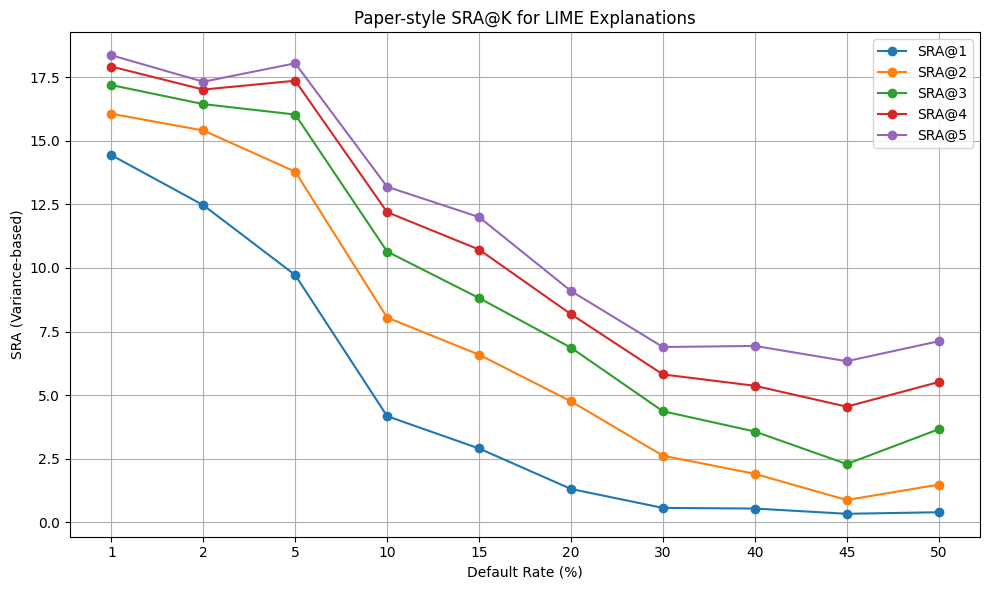

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# === CONFIGURATION ===
ratios = ["1", "2", "5", "10", "15", "20", "30", "40", "45", "50"]
k_list = [1, 2, 3, 4, 5]
sra_scores_lime = {k: [] for k in k_list}

# === FUNCTION: Rank Variance ===
def compute_rank_variance(rankings):
    rankings = np.array(rankings)  # (runs × features)
    mean_rank = np.mean(rankings, axis=0)
    var = np.mean((rankings - mean_rank) ** 2, axis=0)
    return var

# === MAIN LOOP ===
for ratio in ratios:
    print(f"Processing LIME explanations for {ratio}% imbalance")
    
    df = pd.read_csv(f"results/iterations/lime_iterations_{ratio}.csv")
    feature_cols = [col for col in df.columns if col not in ['iteration']]
    
    runs = [df[df['iteration'] == i][feature_cols].values for i in range(100)]
    n_instances = runs[0].shape[0]

    for k in k_list:
        sra_per_instance = []

        for inst_idx in range(n_instances):
            rankings = []

            # Step 1: Convert feature importance → ranks
            for run in runs:
                order = np.argsort(-run[inst_idx])  # descending importance
                rank = np.argsort(order) + 1        # convert to rank (1 = best)
                rankings.append(rank)

            rankings = np.array(rankings)

            # Step 2: Compute variance per feature
            var_per_feature = compute_rank_variance(rankings)

            # Step 3: Get union of top-k features across runs
            topk_features = set()
            for r in rankings:
                topk = np.argsort(r)[:k]
                topk_features.update(topk)

            topk_features = list(topk_features)

            # Step 4: SRA@k = average variance of these features
            sra = np.mean(var_per_feature[topk_features])
            sra_per_instance.append(sra)

        avg_sra = np.mean(sra_per_instance)
        sra_scores_lime[k].append(avg_sra)

# === PLOT ===
plt.figure(figsize=(10, 6))
for k in k_list:
    plt.plot(ratios, sra_scores_lime[k], marker='o', label=f'SRA@{k}')

plt.xlabel("Default Rate (%)")
plt.ylabel("SRA (Variance-based)")
plt.title("Paper-style SRA@K for LIME Explanations")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()